# Agrupamiento de clientes por comportamiento de consumo

Este notebook construye una segmentación no supervisada (clustering) de clientes,
pensada como insumo directo para el estudio de caída de consumo que viene después
(`Estudio_caida_consumo.ipynb`, notebook separado que lee la salida de este).

## Diseño

- **Rural y urbano se agrupan por separado.** Mezclarlos haría que cualquier
  algoritmo separe primero por esa variable (su dinámica de consumo es
  estructuralmente distinta, como ya sabemos) y ahogaría los patrones más finos
  dentro de cada grupo.
- `es_rural` se resuelve en cascada: primero la columna `es_rural` ya calculada
  en el preprocesamiento (por ciclo); para los NIU sin ciclo identificado, se
  usa `candidato_trimestral` de `perfil_periodicidad_clientes.parquet` — que se
  calculó directamente de las fechas reales de lectura, sin depender del ciclo.
  Solo si ninguna de las dos fuentes tiene información (menos de 3 lecturas en
  toda la historia) se cae a urbano por defecto, y queda marcado como tal.
- Se incorpora `consumo_promedio_semestral_kwh` (el promedio semestral que ya
  reporta EBSA en los históricos) como una señal de variabilidad adicional,
  independiente de la que calculamos nosotros mismos — mide qué tan lejos está
  el consumo real de la referencia semestral oficial, no solo de su propio
  historial. Antes de usarlo se audita cómo se comporta este campo (si cambia
  en el tiempo, cobertura de nulos), porque no lo hemos inspeccionado
  directamente todavía.
- **Comparación de algoritmos + Optuna, igual filosofía que el modelado
  supervisado.** No se asume de entrada que MiniBatchKMeans es el mejor:
  se compara contra Gaussian Mixture (clusters elípticos, pertenencia
  probabilística) usando Optuna para ajustar los hiperparámetros de cada
  uno por separado, y se elige el que gane en una muestra de validación
  independiente — el mismo espíritu de "comparación → validación →
  independiente" que ya usamos en el forecasting, adaptado a clustering:
  una muestra para ajustar (`fit`), otra para que Optuna elija
  hiperparámetros, y una tercera, nunca vista por Optuna, para decidir el
  algoritmo ganador.
- Jerárquico y DBSCAN/HDBSCAN se dejan fuera: jerárquico no escala a
  cientos de miles de filas sin aproximaciones, y DBSCAN necesita calibrar
  un radio de vecindad delicado para este tipo de datos.

## Correcciones frente a la primera corrida

La primera versión produjo una segmentación degenerada: el 90,7% de los
urbanos y el 87,5% de los rurales cayeron en un solo cluster, y cuatro de los
nueve clusters tenían 4, 9, 164 y 4 clientes. El silhouette de 0,80 no
contradecía eso — **lo causaba**: aislar un puñado de outliers extremos en su
propio cluster produce un silhouette altísimo y una segmentación inservible.
La raíz estaba en features relativas sin cota (`cv_interno` hasta 3.050,
`pendiente_pct_mensual_12m` hasta −57.854%/mes, `cv_vs_semestral` hasta 486)
que, tras estandarizar, dejaban unos pocos puntos a cientos de desviaciones
del resto dictando toda la geometría.

Tres cambios lo corrigen:

1. **Los grupos estructurales salen por regla, no por algoritmo.** Los
   clientes con el 100% de meses válidos en cero se etiquetan directamente
   (`U_CERO_PERMANENTE` / `R_CERO_PERMANENTE`) y no entran al clustering.
   Es una condición determinística, no algo que haya que descubrir.
2. **Winsorización p1–p99 + `RobustScaler`.** Las tres features sin cota se
   recortan en percentiles robustos, y se escala con mediana/IQR en vez de
   media/desviación, porque media y desviación son justamente las
   estadísticas que los outliers destruyen. Los límites y el escalador se
   ajustan solo sobre la muestra de ajuste.
3. **Restricción de tamaño mínimo dentro de la función objetivo.** Cualquier
   partición con un cluster por debajo del 0,5% de su subpoblación se
   penaliza por debajo de cualquier solución válida, con penalización
   graduada para que Optuna conserve gradiente. Así "ganar" ya no puede
   significar aislar cuatro puntos.

Además, los clusters reciben un **nombre legible derivado de su propio
perfil** (nivel de consumo, estabilidad, tendencia) en vez de los
identificadores arbitrarios `urbano_0`, `rural_2`, que cambian entre corridas.

## Salida

`clientes_clusters_consumo.parquet` — un registro por NIU con sus features,
`es_rural_final`, y `cluster_id`. Ese archivo es lo que va a leer el notebook
del estudio de caída de consumo.


In [38]:
# ============================================================
# 1. LIBRERÍAS Y RUTAS
# ============================================================

from pathlib import Path
import re
import gc

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import joblib
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

try:
    import optuna
except ImportError as e:
    raise ImportError(
        "Falta Optuna. Ejecuta: %pip install -U optuna"
    ) from e

optuna.logging.set_verbosity(optuna.logging.WARNING)

BASE_DIR = Path(r"C:\Users\Home\Documents\Datos Ebsa")

PREPROC_DIR = BASE_DIR / "Serie_tiempo_consumo" / "preprocesamiento_modelo"
SALIDAS_DIR = BASE_DIR / "Serie_tiempo_consumo" / "salidas"
PROCESADO_DIR = BASE_DIR / "Procesado"

AGRUP_DIR = BASE_DIR / "Serie_tiempo_consumo" / "agrupamiento_clientes"
AGRUP_DIR.mkdir(parents=True, exist_ok=True)

RUTA_ENTRADA = PREPROC_DIR / "serie_mensual_modelado_preprocesada.parquet"
RUTA_PERFIL_PERIODICIDAD = SALIDAS_DIR / "perfil_periodicidad_clientes.parquet"

RUTA_FEATURES_CLIENTES = AGRUP_DIR / "features_clientes_consumo.parquet"
RUTA_CLUSTERS = AGRUP_DIR / "clientes_clusters_consumo.parquet"
RUTA_PERFIL_CLUSTERS = AGRUP_DIR / "perfil_clusters_resumen.csv"
RUTA_AUDITORIA_SEMESTRAL = AGRUP_DIR / "auditoria_promedio_semestral.csv"
RUTA_COMPARACION_ALGORITMOS = AGRUP_DIR / "comparacion_algoritmos_clustering.csv"
RUTA_CATALOGO_NEGOCIO = AGRUP_DIR / "catalogo_segmentos_negocio.csv"
RUTA_MODELOS = AGRUP_DIR / "modelo_agrupamiento.joblib"

SEED = 42
MIN_MESES_VALIDOS_12 = 6  # mismo umbral que ya usa el modelado (P4_INSUFICIENTE)

# --- Retroceso de la ventana por truncamiento del último mes ---------------
# El diagnóstico del estudio de caída detectó que en RURAL el último periodo
# (2026-01) trae un consumo medio del 47.9% de lo normal, con cobertura de
# clientes intacta (101%): no faltan lecturas, falta consumo. Es el borde de
# la reconstrucción trimestral, que reparte una lectura larga entre meses y
# deja el último tramo incompleto.
#
# El efecto no es menor: sobre una serie REALMENTE plana, un último mes al
# 47.9% produce por sí solo una pendiente de -2.00 %/mes. La pendiente que
# medimos en el rural era -2.29 %/mes, así que casi toda la "caída rural"
# era este artefacto, no comportamiento de los clientes.
#
# Con retroceso de 1 mes la ventana termina en el último periodo completo.
MESES_RETROCESO_VENTANA = 1
N_TRIALS_CLUSTERING = 25  # intentos de Optuna por algoritmo x subpoblación

# --- Correcciones para evitar segmentaciones degeneradas -------------------
# En la primera corrida el 90% de los urbanos cayó en un solo cluster y cuatro
# clusters tenían 4, 9, 164 y 4 clientes. Causa: features relativas sin cota
# (cv_interno hasta 3.050, pendiente hasta -57.854%/mes) que, al estandarizar,
# dejan un puñado de puntos a cientos de desviaciones del resto y dictan toda
# la geometría. El silhouette premia justamente eso: aislar 4 outliers da un
# silhouette altísimo y una segmentación inútil.
MIN_SHARE_CLUSTER = 0.005   # ningún cluster puede tener < 0.5% de su subpoblación
WINSOR_P_BAJO = 1           # percentil inferior de recorte (winsorización)
WINSOR_P_ALTO = 99          # percentil superior de recorte

print("Entrada principal   :", RUTA_ENTRADA)
print("Perfil periodicidad :", RUTA_PERFIL_PERIODICIDAD)
print("Históricos          :", PROCESADO_DIR)
print("Salidas             :", AGRUP_DIR)


Entrada principal   : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\preprocesamiento_modelo\serie_mensual_modelado_preprocesada.parquet
Perfil periodicidad : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\salidas\perfil_periodicidad_clientes.parquet
Históricos          : C:\Users\Home\Documents\Datos Ebsa\Procesado
Salidas             : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes


## Cargar serie preprocesada y resolver zona rural/urbana

In [39]:
# ============================================================
# 2. CARGAR SERIE PREPROCESADA
# ============================================================

if not RUTA_ENTRADA.exists():
    raise FileNotFoundError(f"No existe:\n{RUTA_ENTRADA}")

serie = pd.read_parquet(RUTA_ENTRADA, engine="pyarrow")

serie["NIU"] = serie["NIU"].astype("string").str.strip()
serie["periodo"] = pd.to_datetime(serie["periodo"], errors="coerce")
serie["consumo_kwh_mensual"] = pd.to_numeric(
    serie["consumo_kwh_mensual"], errors="coerce"
).astype("float32")

if "es_rural" not in serie.columns:
    raise ValueError(
        "La serie preprocesada no tiene la columna es_rural. "
        "Corre primero la celda 9b del notebook de preprocesamiento."
    )

periodo_min = serie["periodo"].min().to_period("M").to_timestamp()
periodo_max = serie["periodo"].max().to_period("M").to_timestamp()

print("VALIDACIÓN DE ENTRADA")
print("-" * 60)
print(f"Filas       : {len(serie):,}")
print(f"NIU únicos  : {serie['NIU'].nunique():,}")
print(f"Periodo     : {periodo_min:%Y-%m} → {periodo_max:%Y-%m}")


VALIDACIÓN DE ENTRADA
------------------------------------------------------------
Filas       : 26,888,751
NIU únicos  : 592,159
Periodo     : 2022-01 → 2026-01


In [40]:
# ============================================================
# 3. RESOLVER es_rural_final (ciclo -> candidato_trimestral -> urbano por defecto)
# ============================================================

es_rural_por_niu = (
    serie.drop_duplicates("NIU")[["NIU", "es_rural"]]
    .set_index("NIU")["es_rural"]
)

n_con_ciclo = int(es_rural_por_niu.notna().sum())
n_sin_ciclo = int(es_rural_por_niu.isna().sum())

print("PASO 1 — es_rural por ciclo (preprocesamiento)")
print("-" * 60)
print(f"NIU con ciclo identificado    : {n_con_ciclo:,}")
print(f"NIU SIN ciclo identificado    : {n_sin_ciclo:,}")

# --- Resolver los sin ciclo con candidato_trimestral (fechas reales) ---
if not RUTA_PERFIL_PERIODICIDAD.exists():
    raise FileNotFoundError(f"No existe:\n{RUTA_PERFIL_PERIODICIDAD}")

perfil_periodicidad = pd.read_parquet(
    RUTA_PERFIL_PERIODICIDAD,
    columns=["NIU", "candidato_trimestral"],
    engine="pyarrow",
)
perfil_periodicidad["NIU"] = (
    perfil_periodicidad["NIU"].astype("string").str.strip()
)

candidato_por_niu = (
    perfil_periodicidad
    .drop_duplicates("NIU")
    .set_index("NIU")["candidato_trimestral"]
)

niu_sin_ciclo = es_rural_por_niu[es_rural_por_niu.isna()].index

resuelto_por_fechas = candidato_por_niu.reindex(niu_sin_ciclo)

n_resueltos_por_fechas = int(resuelto_por_fechas.notna().sum())
n_sin_ninguna_fuente = int(resuelto_por_fechas.isna().sum())

print("\nPASO 2 — resolver los sin ciclo con candidato_trimestral (fechas reales)")
print("-" * 60)
print(f"Resueltos por patrón de fechas real : {n_resueltos_por_fechas:,}")
print(f"Sin ninguna fuente (< 3 lecturas)    : {n_sin_ninguna_fuente:,}")

es_rural_final = es_rural_por_niu.copy()
es_rural_final.loc[niu_sin_ciclo] = resuelto_por_fechas.astype("boolean")

# Fuente de la clasificación, para que quede auditable
fuente_clasificacion = pd.Series("ciclo", index=es_rural_final.index, dtype="string")
fuente_clasificacion.loc[niu_sin_ciclo] = "fechas_reales"

niu_sin_ninguna_fuente = resuelto_por_fechas[resuelto_por_fechas.isna()].index
fuente_clasificacion.loc[niu_sin_ninguna_fuente] = "urbano_por_defecto_sin_datos"

# Última red de seguridad: si todavía queda algún <NA>, urbano por defecto
n_aun_na = int(es_rural_final.isna().sum())
if n_aun_na > 0:
    es_rural_final = es_rural_final.fillna(False)

es_rural_final = es_rural_final.astype(bool)

print("\nPASO 3 — clasificación final")
print("-" * 60)
resumen_fuente = (
    fuente_clasificacion
    .value_counts()
    .rename("n_clientes")
    .to_frame()
)
display(resumen_fuente)

resumen_rural_final = (
    es_rural_final
    .value_counts()
    .rename("n_clientes")
    .to_frame()
)
display(resumen_rural_final)


PASO 1 — es_rural por ciclo (preprocesamiento)
------------------------------------------------------------
NIU con ciclo identificado    : 591,382
NIU SIN ciclo identificado    : 777

PASO 2 — resolver los sin ciclo con candidato_trimestral (fechas reales)
------------------------------------------------------------
Resueltos por patrón de fechas real : 777
Sin ninguna fuente (< 3 lecturas)    : 0

PASO 3 — clasificación final
------------------------------------------------------------


,n_clientes
ciclo,591382
fechas_reales,777


,n_clientes
es_rural,
False,372799
True,219360


## Auditar e incorporar el promedio semestral reportado por EBSA

In [41]:
# ============================================================
# 4. LOCALIZAR HISTÓRICOS Y LEER consumo_promedio_semestral_kwh
# ============================================================

patron = re.compile(r"^historico_(20\d{2})\.parquet$", re.IGNORECASE)

archivos_historicos = sorted(
    [p for p in PROCESADO_DIR.glob("historico_*.parquet") if patron.match(p.name)],
    key=lambda p: int(patron.match(p.name).group(1)),
)

if not archivos_historicos:
    raise FileNotFoundError(f"No se encontraron historico_YYYY.parquet en:\n{PROCESADO_DIR}")

COL_SEMESTRAL = "consumo_promedio_semestral_kwh"

partes_semestral = []

for ruta in archivos_historicos:
    columnas_archivo = pq.ParquetFile(ruta).schema_arrow.names

    necesarias = [c for c in ["NIU", "periodo", COL_SEMESTRAL] if c in columnas_archivo]

    if COL_SEMESTRAL not in necesarias:
        print(f"⚠ {ruta.name} no tiene la columna {COL_SEMESTRAL}, se omite.")
        continue

    temp = pd.read_parquet(ruta, columns=necesarias, engine="pyarrow")
    temp["archivo_historico"] = ruta.name
    partes_semestral.append(temp)

if not partes_semestral:
    raise ValueError(
        f"Ningún histórico tiene la columna {COL_SEMESTRAL}. "
        "Revisa el nombre exacto de la columna en tus archivos."
    )

metadata_semestral = pd.concat(partes_semestral, ignore_index=True, sort=False)

metadata_semestral["NIU"] = metadata_semestral["NIU"].astype("string").str.strip()
metadata_semestral["periodo"] = pd.to_datetime(metadata_semestral["periodo"], errors="coerce")
metadata_semestral[COL_SEMESTRAL] = pd.to_numeric(
    metadata_semestral[COL_SEMESTRAL], errors="coerce"
)

print("Metadatos de promedio semestral cargados")
print(f"Filas      : {len(metadata_semestral):,}")
print(f"NIU únicos : {metadata_semestral['NIU'].nunique():,}")


Metadatos de promedio semestral cargados
Filas      : 20,226,965
NIU únicos : 592,186


In [42]:
# ============================================================
# 5. AUDITAR EL COMPORTAMIENTO DE consumo_promedio_semestral_kwh
# ============================================================
# No hemos inspeccionado este campo antes. Antes de construir cualquier
# feature con él, se audita: cobertura de nulos, y si cambia en el tiempo
# para un mismo cliente (¿es un valor fijo, o se recalcula periódicamente?).
# ============================================================

n_filas = len(metadata_semestral)
n_nulos = int(metadata_semestral[COL_SEMESTRAL].isna().sum())

print("COBERTURA")
print("-" * 60)
print(f"Filas totales      : {n_filas:,}")
print(f"Nulos              : {n_nulos:,} ({n_nulos / n_filas * 100:.2f}%)")
print(f"No nulos           : {n_filas - n_nulos:,}")

valores_por_niu = (
    metadata_semestral
    .dropna(subset=[COL_SEMESTRAL])
    .groupby("NIU")[COL_SEMESTRAL]
    .nunique()
)

print("\n¿CAMBIA EN EL TIEMPO PARA UN MISMO CLIENTE?")
print("-" * 60)
print("Distribución de valores DISTINTOS no nulos por NIU:")
display(
    valores_por_niu
    .value_counts()
    .sort_index()
    .rename("n_clientes")
    .to_frame()
    .head(10)
)

pct_estable = float((valores_por_niu <= 1).mean() * 100)
print(f"\n% de clientes con un único valor a lo largo del tiempo: {pct_estable:.2f}%")

resumen_auditoria_semestral = pd.DataFrame([
    ["filas_totales", n_filas],
    ["nulos", n_nulos],
    ["pct_nulos", round(n_nulos / n_filas * 100, 2)],
    ["niu_con_al_menos_un_valor", int(valores_por_niu.shape[0])],
    ["pct_niu_valor_estable", round(pct_estable, 2)],
], columns=["metrica", "valor"])

display(resumen_auditoria_semestral)

resumen_auditoria_semestral.to_csv(
    RUTA_AUDITORIA_SEMESTRAL, index=False, encoding="utf-8-sig",
)

print(
    "\nSi el % de valor estable es alto, se trata como un valor de referencia "
    "casi fijo por cliente y se usa el más reciente no nulo. Si cambia mucho, "
    "sigue siendo válido usar el más reciente — es la referencia vigente en "
    "el momento actual — pero conviene saberlo antes de interpretar resultados."
)


COBERTURA
------------------------------------------------------------
Filas totales      : 20,226,965
Nulos              : 0 (0.00%)
No nulos           : 20,226,965

¿CAMBIA EN EL TIEMPO PARA UN MISMO CLIENTE?
------------------------------------------------------------
Distribución de valores DISTINTOS no nulos por NIU:


,n_clientes
consumo_promedio_semestral_kwh,
1,28202
2,10429
3,10424
4,10694
5,11366
6,12176
7,11983
8,13523
9,15181



% de clientes con un único valor a lo largo del tiempo: 4.76%


,metrica,valor
0,filas_totales,20226965.00
1,nulos,0.00
2,pct_nulos,0.00
3,niu_con_al_menos_un_valor,592186.00
4,pct_niu_valor_estable,4.76



Si el % de valor estable es alto, se trata como un valor de referencia casi fijo por cliente y se usa el más reciente no nulo. Si cambia mucho, sigue siendo válido usar el más reciente — es la referencia vigente en el momento actual — pero conviene saberlo antes de interpretar resultados.


In [43]:
# ============================================================
# 6. PROMEDIO SEMESTRAL DE REFERENCIA POR CLIENTE (VALOR MÁS RECIENTE NO NULO)
# ============================================================

promedio_semestral_ref = (
    metadata_semestral
    .dropna(subset=[COL_SEMESTRAL])
    .sort_values("periodo")
    .drop_duplicates("NIU", keep="last")
    .set_index("NIU")[COL_SEMESTRAL]
    .rename("promedio_semestral_ref")
)

print(f"NIU con promedio semestral de referencia: {len(promedio_semestral_ref):,}")
display(promedio_semestral_ref.describe())


NIU con promedio semestral de referencia: 592,186


count    592186.000000
mean        119.598129
std        2087.376939
min           0.000000
25%          17.000000
50%          53.000000
75%          99.000000
max      691536.000000
Name: promedio_semestral_ref, dtype: float64

## Construir features de comportamiento por cliente (ventana de 12 meses)

In [44]:
# ============================================================
# 7. MATRIZ DE CONSUMO NIU x MES (últimos 12 meses hasta periodo_max)
# ============================================================

# --- VERIFICAR EL BORDE ANTES DE FIJAR LA VENTANA ---
# Se comprueba en los datos que el retroceso configurado es el correcto,
# en vez de darlo por sentado.
meses_chequeo = pd.date_range(end=periodo_max, periods=15, freq="MS")
borde = (
    serie[serie["periodo"].isin(meses_chequeo)]
    .groupby(["es_rural", "periodo"])["consumo_kwh_mensual"]
    .agg(clientes="count", consumo_medio="mean")
    .reset_index()
)
borde["zona"] = np.where(borde["es_rural"].fillna(False), "RURAL", "URBANO")

print("CHEQUEO DEL BORDE DE LA SERIE (últimos 3 meses vs. mediana previa)")
print("-" * 70)
meses_truncados = 0
for zona, grupo in borde.groupby("zona"):
    grupo = grupo.sort_values("periodo")
    ref = grupo["consumo_medio"].iloc[:-3].median()
    for _, f in grupo.tail(3).iterrows():
        pct = f["consumo_medio"] / ref * 100
        marca = "  <-- TRUNCADO" if pct < 85 else ""
        print(f"  {zona:<7} {f['periodo']:%Y-%m}: {pct:6.1f}% del nivel normal{marca}")
        if pct < 85 and f["periodo"] > periodo_max - pd.DateOffset(months=MESES_RETROCESO_VENTANA):
            meses_truncados += 1

print(f"\nRetroceso configurado: {MESES_RETROCESO_VENTANA} mes(es)")
if meses_truncados:
    print("✓ El retroceso excluye el/los mes(es) truncado(s).")
else:
    print("  Ningún mes truncado dentro del tramo excluido — revisa si el "
          "retroceso sigue haciendo falta.")

periodo_fin_ventana = periodo_max - pd.DateOffset(months=MESES_RETROCESO_VENTANA)
meses_12 = pd.date_range(end=periodo_fin_ventana, periods=12, freq="MS")

# Universo COMPLETO de clientes (592,159 NIU), no solo los que tienen
# alguna fila dentro de los últimos 12 meses — así un cliente sin datos
# recientes queda con toda la fila en NaN y termina marcado más adelante
# como "historia insuficiente", en vez de desaparecer silenciosamente.
todos_los_niu = pd.Index(
    serie["NIU"].astype("string").unique(), name="NIU"
).sort_values()

wide_consumo = (
    serie[serie["periodo"].isin(meses_12)]
    [["NIU", "periodo", "consumo_kwh_mensual"]]
    .pivot(index="NIU", columns="periodo", values="consumo_kwh_mensual")
    .reindex(index=todos_los_niu, columns=meses_12)
    .astype("float32")
)

nius = wide_consumo.index.astype("string").to_numpy()
ventana_12m = wide_consumo.to_numpy(dtype="float32", copy=False)

print(f"Universo completo de NIU incluido en la matriz: {len(nius):,}")
print("Ventana 12 meses:", f"{meses_12[0]:%Y-%m}", "→", f"{meses_12[-1]:%Y-%m}")
print("Matriz:", ventana_12m.shape)

del wide_consumo
gc.collect()


CHEQUEO DEL BORDE DE LA SERIE (últimos 3 meses vs. mediana previa)
----------------------------------------------------------------------
  RURAL   2025-11:  102.6% del nivel normal
  RURAL   2025-12:  105.9% del nivel normal
  RURAL   2026-01:   47.9% del nivel normal  <-- TRUNCADO
  URBANO  2025-11:   97.4% del nivel normal
  URBANO  2025-12:   96.2% del nivel normal
  URBANO  2026-01:   97.0% del nivel normal

Retroceso configurado: 1 mes(es)
✓ El retroceso excluye el/los mes(es) truncado(s).
Universo completo de NIU incluido en la matriz: 592,159
Ventana 12 meses: 2025-01 → 2025-12
Matriz: (592159, 12)


11094

In [45]:
# ============================================================
# 8. FEATURES DE NIVEL, VOLATILIDAD, CEROS Y TENDENCIA
# ============================================================

es_valido = ~np.isnan(ventana_12m)
validos_12m = es_valido.sum(axis=1)

def mediana_nan(a):
    salida = np.full(len(a), np.nan, dtype="float64")
    mask = np.any(~np.isnan(a), axis=1)
    if mask.any():
        salida[mask] = np.nanmedian(a[mask], axis=1)
    return salida

def std_nan(a):
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.nanstd(a, axis=1).astype("float64")

def pendiente_nan(a):
    """Pendiente de consumo por mes (regresión lineal simple),
    ignorando meses sin dato. Devuelve NaN si hay menos de 2
    meses válidos."""
    n_filas, n_meses = a.shape
    x = np.arange(n_meses, dtype="float64")
    mask = ~np.isnan(a)
    n = mask.sum(axis=1).astype("float64")

    x_bcast = np.broadcast_to(x, a.shape)
    sum_x = np.where(mask, x_bcast, 0.0).sum(axis=1)
    sum_x2 = np.where(mask, x_bcast ** 2, 0.0).sum(axis=1)
    sum_y = np.nansum(a, axis=1)
    sum_xy = np.nansum(x_bcast * a, axis=1)

    salida = np.full(n_filas, np.nan, dtype="float64")

    valido = n >= 2
    mean_x = sum_x[valido] / n[valido]
    mean_y = sum_y[valido] / n[valido]
    var_x = sum_x2[valido] / n[valido] - mean_x ** 2
    cov_xy = sum_xy[valido] / n[valido] - mean_x * mean_y

    con_varianza = var_x > 0
    idx_valido = np.flatnonzero(valido)
    salida[idx_valido[con_varianza]] = (
        cov_xy[con_varianza] / var_x[con_varianza]
    )

    return salida

mediana_12m = mediana_nan(ventana_12m)
std_12m = std_nan(ventana_12m)
ceros_12m = np.where(es_valido, ventana_12m == 0, False).sum(axis=1)

pct_ceros_12m = np.full(len(nius), np.nan, dtype="float64")
mask_validos = validos_12m > 0
pct_ceros_12m[mask_validos] = ceros_12m[mask_validos] / validos_12m[mask_validos]

# Coeficiente de variación interno (auto-referencia)
cv_interno = np.full(len(nius), np.nan, dtype="float64")
mask_cv = mediana_12m > 0
cv_interno[mask_cv] = std_12m[mask_cv] / mediana_12m[mask_cv]

pendiente_12m = pendiente_nan(ventana_12m)

# Pendiente normalizada por nivel: % de cambio promedio por mes
pendiente_pct_12m = np.full(len(nius), np.nan, dtype="float64")
mask_pend = mediana_12m > 0
pendiente_pct_12m[mask_pend] = pendiente_12m[mask_pend] / mediana_12m[mask_pend] * 100

print("Features de nivel/volatilidad/tendencia calculadas.")
print(f"NIU con mediana_12m válida: {int(mask_cv.sum()):,} de {len(nius):,}")


Features de nivel/volatilidad/tendencia calculadas.
NIU con mediana_12m válida: 535,694 de 592,159


c:\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [46]:
# ============================================================
# 9. VOLATILIDAD VS. PROMEDIO SEMESTRAL DE EBSA (SEÑAL EXTERNA)
# ============================================================
# Distinto al cv_interno: aquí se mide qué tan lejos está el consumo real
# de la referencia semestral que ya reporta EBSA, no de su propio historial.
# ============================================================

promedio_semestral_alineado = (
    pd.Series(promedio_semestral_ref, index=promedio_semestral_ref.index)
    .reindex(nius)
    .to_numpy(dtype="float64")
)

desviacion_vs_semestral = ventana_12m.astype("float64") - promedio_semestral_alineado[:, None]

cv_vs_semestral = np.full(len(nius), np.nan, dtype="float64")
mask_semestral = (promedio_semestral_alineado > 0) & (validos_12m > 0)

with np.errstate(invalid="ignore"):
    std_desv = np.nanstd(desviacion_vs_semestral, axis=1)

cv_vs_semestral[mask_semestral] = (
    std_desv[mask_semestral] / promedio_semestral_alineado[mask_semestral]
)

n_con_semestral = int(mask_semestral.sum())
print(
    f"NIU con volatilidad vs. promedio semestral calculada: "
    f"{n_con_semestral:,} de {len(nius):,} "
    f"({n_con_semestral / len(nius) * 100:.1f}%)"
)

del desviacion_vs_semestral
gc.collect()


NIU con volatilidad vs. promedio semestral calculada: 524,017 de 592,159 (88.5%)


c:\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


0

In [47]:
# ============================================================
# 10. ENSAMBLAR TABLA DE FEATURES POR CLIENTE
# ============================================================

features_clientes = pd.DataFrame({
    "NIU": nius,
    "meses_validos_12m": validos_12m.astype("int16"),
    "mediana_12m_kwh": mediana_12m,
    "std_12m_kwh": std_12m,
    "cv_interno": cv_interno,
    "pct_ceros_12m": pct_ceros_12m,
    "pendiente_pct_mensual_12m": pendiente_pct_12m,
    "promedio_semestral_ref_kwh": promedio_semestral_alineado,
    "cv_vs_semestral": cv_vs_semestral,
})

features_clientes = features_clientes.merge(
    es_rural_final.rename("es_rural_final").reset_index().rename(columns={"index": "NIU"}),
    on="NIU",
    how="left",
)

features_clientes = features_clientes.merge(
    fuente_clasificacion.rename("fuente_clasificacion_rural").reset_index().rename(columns={"index": "NIU"}),
    on="NIU",
    how="left",
)

features_clientes["historia_suficiente"] = (
    features_clientes["meses_validos_12m"] >= MIN_MESES_VALIDOS_12
)

print("HISTORIA SUFICIENTE PARA AGRUPAR (>= {} meses válidos en 12m)".format(MIN_MESES_VALIDOS_12))
display(
    features_clientes["historia_suficiente"]
    .value_counts()
    .rename("n_clientes")
    .to_frame()
)

features_clientes.to_parquet(RUTA_FEATURES_CLIENTES, index=False, engine="pyarrow")
print("\nGuardado:", RUTA_FEATURES_CLIENTES)

display(features_clientes.head(10))


HISTORIA SUFICIENTE PARA AGRUPAR (>= 6 meses válidos en 12m)


,n_clientes
historia_suficiente,
True,570368
False,21791



Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\features_clientes_consumo.parquet


,NIU,meses_validos_12m,mediana_12m_kwh,std_12m_kwh,cv_interno,pct_ceros_12m,pendiente_pct_mensual_12m,promedio_semestral_ref_kwh,cv_vs_semestral,es_rural_final,fuente_clasificacion_rural,historia_suficiente
0,1000006589,12,43.500000,38.428143,0.883406,0.0,7.378828,55.0,0.698694,False,ciclo,True
1,1000007366,12,76.500000,9.050399,0.118306,0.0,1.997349,78.0,0.116031,False,ciclo,True
2,1000008143,12,49.000000,14.042347,0.286579,0.0,-1.562723,49.0,0.286579,False,ciclo,True
3,100000949,12,40.339081,10.909246,0.270439,0.0,5.323766,42.0,0.259744,True,ciclo,True
4,1000009920,12,75.500000,14.924579,0.197677,0.0,2.764785,74.0,0.201683,False,ciclo,True
5,1000010766,12,96.500000,11.665476,0.120886,0.0,-0.688431,94.0,0.124101,False,ciclo,True
6,100001726,12,0.000000,0.000000,NaN,1.0,NaN,0.0,NaN,True,ciclo,True
7,100002503,12,13.784559,1.322249,0.095923,0.0,0.654143,13.0,0.101711,True,ciclo,True
8,100003390,12,31.250000,4.075477,0.130415,0.0,-2.430281,29.0,0.140534,True,ciclo,True
9,100004177,12,39.481384,10.150595,0.257098,0.0,6.155366,44.0,0.230695,True,ciclo,True


## Separar por regla los grupos estructurales, y preparar el resto para agrupar

Un cliente con el **100% de sus meses válidos en cero** no es un descubrimiento
del algoritmo: es una regla determinística. Dejarlo dentro del clustering
obliga al modelo a gastar un cluster entero en reproducir una condición que ya
conocemos, y además mete un bloque enorme de puntos idénticos que distorsiona
la geometría del resto.

Se etiquetan aparte (`U_CERO_PERMANENTE` / `R_CERO_PERMANENTE`) y el
agrupamiento trabaja solo sobre la población **activa**, que es donde
realmente hay variación que descubrir.


In [48]:
# ============================================================
# 11. PREPARAR FEATURES Y SEPARAR LOS GRUPOS ESTRUCTURALES POR REGLA
# ============================================================
# log1p en variables de magnitud (muy sesgadas). cv_interno / cv_vs_semestral
# / pendiente ya son medidas relativas, no necesitan log1p, pero sí
# escalamiento robusto (eso lo hace preparar_muestras más adelante).
# ============================================================

COLUMNAS_CLUSTERING = [
    "mediana_12m_kwh_log",
    "cv_interno",
    "pct_ceros_12m",
    "pendiente_pct_mensual_12m",
    "cv_vs_semestral",
]

# Features sin cota superior natural: son las que hay que winsorizar.
# pct_ceros_12m ya vive en [0,1] y mediana_12m_kwh_log ya está comprimida
# por el log, así que no se tocan.
COLUMNAS_WINSOR = [
    "cv_interno",
    "pendiente_pct_mensual_12m",
    "cv_vs_semestral",
]

base_clustering = features_clientes[features_clientes["historia_suficiente"]].copy()

base_clustering["mediana_12m_kwh_log"] = np.log1p(
    base_clustering["mediana_12m_kwh"].clip(lower=0)
)

# --- REGLA 1: cero permanente (100% de meses válidos en cero) ---
es_cero_permanente = base_clustering["pct_ceros_12m"] >= 1.0

segmento_regla = base_clustering.loc[es_cero_permanente, ["NIU", "es_rural_final"]].copy()
segmento_regla["asignado_por"] = "regla"

print("GRUPOS ESTRUCTURALES SEPARADOS POR REGLA")
print("-" * 60)
print("(reciben el nombre de negocio SIN_CONSUMO más adelante)")
display(
    segmento_regla["es_rural_final"]
    .map({True: "RURAL", False: "URBANO"})
    .value_counts()
    .rename("n_clientes")
    .to_frame()
)

# --- Población activa: la que sí va al algoritmo de clustering ---
base_activa = base_clustering.loc[~es_cero_permanente].copy()

# Imputación explícita: mediana de la propia columna, separada por
# es_rural_final para no mezclar escalas. Se calcula SOBRE LA POBLACIÓN
# ACTIVA, no sobre el total — si no, los ceros permanentes arrastrarían
# las medianas hacia abajo.
for col in COLUMNAS_CLUSTERING:
    faltantes = base_activa[col].isna()
    if faltantes.any():
        medianas_grupo = (
            base_activa
            .groupby("es_rural_final")[col]
            .transform("median")
        )
        base_activa.loc[faltantes, col] = medianas_grupo[faltantes]

print(f"\nPoblación activa que va al clustering: {len(base_activa):,}")
print("Nulos por columna después de imputar (deberían ser 0):")
display(base_activa[COLUMNAS_CLUSTERING].isna().sum())

urbanos = base_activa[~base_activa["es_rural_final"]].copy()
rurales = base_activa[base_activa["es_rural_final"]].copy()

print(f"\nUrbanos activos a agrupar: {len(urbanos):,}")
print(f"Rurales activos a agrupar: {len(rurales):,}")

print("\nCOLAS EXTREMAS ANTES DE WINSORIZAR (esto es lo que rompía la corrida anterior)")
print("-" * 60)
display(base_activa[COLUMNAS_WINSOR].describe(percentiles=[0.01, 0.5, 0.99]).T)


GRUPOS ESTRUCTURALES SEPARADOS POR REGLA
------------------------------------------------------------
(reciben el nombre de negocio SIN_CONSUMO más adelante)


,n_clientes
es_rural_final,
RURAL,15794
URBANO,8427



Población activa que va al clustering: 546,147
Nulos por columna después de imputar (deberían ser 0):


mediana_12m_kwh_log          0
cv_interno                   0
pct_ceros_12m                0
pendiente_pct_mensual_12m    0
cv_vs_semestral              0
dtype: int64


Urbanos activos a agrupar: 346,665
Rurales activos a agrupar: 199,482

COLAS EXTREMAS ANTES DE WINSORIZAR (esto es lo que rompía la corrida anterior)
------------------------------------------------------------


,count,mean,std,min,1%,50%,99%,max
cv_interno,546147.0,0.712997,9.752682,0.000000,0.040031,0.196261,7.695532,3802.828491
pendiente_pct_mensual_12m,546147.0,-0.623769,187.208213,-79909.843173,-63.621904,-0.140390,60.954445,16848.251748
cv_vs_semestral,546147.0,0.454771,2.978594,0.000000,0.040612,0.198376,3.978822,976.740366


## Comparar algoritmos (MiniBatchKMeans vs Gaussian Mixture) y ajustar hiperparámetros con Optuna

Para cada subpoblación (urbano, rural) se separan tres muestras disjuntas:
una para **ajustar** el modelo (`fit`), otra para que **Optuna elija
hiperparámetros** maximizando el silhouette score, y una tercera —nunca vista
por Optuna— para la **comparación final independiente** entre los dos
algoritmos. El ganador de esa comparación se reentrena sobre toda la
subpoblación para la asignación de clusters final.


In [49]:
# ============================================================
# 12. PREPROCESO ROBUSTO + MUESTREO EN TRES PARTES
# ============================================================
# Dos cambios frente a la primera corrida:
#   - Winsorización p1-p99 de las features sin cota, para que un puñado de
#     clientes extremos no dicte la geometría del espacio.
#   - RobustScaler (mediana / IQR) en vez de StandardScaler (media / std),
#     porque la media y la desviación estándar son justamente las estadísticas
#     que los outliers destruyen.
# Los límites de recorte y el escalador se ajustan SOLO sobre la muestra de
# ajuste, y se aplican tal cual al resto — misma disciplina de no filtrar
# información entre muestras que usamos en el modelado supervisado.
# ============================================================

def calcular_limites_winsor(datos_fit, columnas):
    limites = {}
    for col in columnas:
        if col in COLUMNAS_WINSOR:
            limites[col] = (
                float(np.nanpercentile(datos_fit[col], WINSOR_P_BAJO)),
                float(np.nanpercentile(datos_fit[col], WINSOR_P_ALTO)),
            )
    return limites


def aplicar_preproceso(datos, columnas, preproceso):
    """Winsoriza con los límites de la muestra de ajuste y escala."""
    X = datos[columnas].copy()
    for col, (lo, hi) in preproceso["limites"].items():
        X[col] = X[col].clip(lower=lo, upper=hi)
    return preproceso["scaler"].transform(X.to_numpy(dtype="float64"))


def preparar_muestras(datos, columnas, fit_n, optuna_n, val_n, seed):

    rng = np.random.default_rng(seed)
    n = len(datos)
    idx = rng.permutation(n)

    # Si la subpoblación no alcanza para los tres tamaños pedidos, se reparte
    # proporcionalmente en vez de dejar vacías las muestras de optimización y
    # validación (que dejaría la comparación de algoritmos sin fundamento).
    pedido_total = fit_n + optuna_n + val_n
    if n < pedido_total:
        factor = n / pedido_total
        fit_n = max(int(fit_n * factor), 1)
        optuna_n = max(int(optuna_n * factor), 1)
        val_n = max(n - fit_n - optuna_n, 1)
        print(
            f"  ⚠ Subpoblación de {n:,} clientes, menor que los {pedido_total:,} "
            f"pedidos: se reparte proporcionalmente."
        )

    idx_fit = idx[:fit_n]
    resto = idx[fit_n:]

    optuna_n = min(optuna_n, len(resto))
    idx_optuna = resto[:optuna_n]
    resto2 = resto[optuna_n:]

    val_n = min(val_n, len(resto2))
    idx_val = resto2[:val_n]

    if len(idx_optuna) == 0 or len(idx_val) == 0:
        raise ValueError(
            f"Subpoblación demasiado pequeña ({n:,}) para separar muestras "
            "de optimización y validación independientes."
        )

    datos_fit = datos.iloc[idx_fit]

    limites = calcular_limites_winsor(datos_fit, columnas)

    # Ajustar el escalador sobre la muestra de ajuste YA winsorizada
    X_fit_bruto = datos_fit[columnas].copy()
    for col, (lo, hi) in limites.items():
        X_fit_bruto[col] = X_fit_bruto[col].clip(lower=lo, upper=hi)

    scaler = RobustScaler()
    X_fit = scaler.fit_transform(X_fit_bruto.to_numpy(dtype="float64"))

    preproceso = {"limites": limites, "scaler": scaler, "columnas": columnas}

    X_optuna = aplicar_preproceso(datos.iloc[idx_optuna], columnas, preproceso)
    X_val = aplicar_preproceso(datos.iloc[idx_val], columnas, preproceso)

    print("  Límites de winsorización (p{}-p{}) desde la muestra de ajuste:".format(
        WINSOR_P_BAJO, WINSOR_P_ALTO
    ))
    for col, (lo, hi) in limites.items():
        print(f"    {col:<28} [{lo:,.3f} , {hi:,.3f}]")

    return X_fit, X_optuna, X_val, preproceso


In [50]:
# ============================================================
# 13. MÉTRICA DE CALIDAD CON PENALIZACIÓN POR CLUSTERS DIMINUTOS
# ============================================================
# Corrección clave. El silhouette por sí solo premia aislar un puñado de
# outliers en su propio cluster: esos puntos quedan perfectamente cohesionados
# y lejísimos de todo, y el score se dispara. Fue exactamente lo que pasó en
# la primera corrida (silhouette 0.80 con clusters de 4 y 9 clientes).
#
# Aquí cualquier partición con un cluster por debajo de MIN_SHARE_CLUSTER
# cae al rango [-2, -1), siempre por debajo del peor silhouette válido (-1),
# pero ordenada: mientras menos degenerada, mejor puntúa. Así Optuna conserva
# un gradiente hacia soluciones sanas en vez de ver una meseta plana.
# ============================================================

def evaluar_particion(X_eval, etiquetas):

    n_grupos = len(np.unique(etiquetas))
    if n_grupos < 2:
        return -2.0

    _, conteos = np.unique(etiquetas, return_counts=True)
    share_min = float(conteos.min()) / len(etiquetas)

    if share_min < MIN_SHARE_CLUSTER:
        return -1.0 - (MIN_SHARE_CLUSTER - share_min) / MIN_SHARE_CLUSTER

    return float(silhouette_score(X_eval, etiquetas))


def resumen_tamanos(etiquetas):
    valores, conteos = np.unique(etiquetas, return_counts=True)
    total = len(etiquetas)
    return ", ".join(
        f"{v}:{c:,} ({c / total * 100:.1f}%)" for v, c in zip(valores, conteos)
    )


In [51]:
# ============================================================
# 13b. FUNCIONES OBJETIVO DE OPTUNA POR ALGORITMO
# ============================================================

def objetivo_minibatchkmeans(trial, X_fit, X_eval):
    n_clusters = trial.suggest_int("n_clusters", 3, 10)
    init = trial.suggest_categorical("init", ["k-means++", "random"])
    n_init = trial.suggest_int("n_init", 3, 15)
    max_iter = trial.suggest_int("max_iter", 100, 300)
    reassignment_ratio = trial.suggest_float(
        "reassignment_ratio", 0.005, 0.05, log=True
    )

    modelo = MiniBatchKMeans(
        n_clusters=n_clusters,
        init=init,
        n_init=n_init,
        max_iter=max_iter,
        reassignment_ratio=reassignment_ratio,
        batch_size=4096,
        random_state=SEED,
    )
    modelo.fit(X_fit)
    etiquetas_eval = modelo.predict(X_eval)

    return evaluar_particion(X_eval, etiquetas_eval)


def objetivo_gmm(trial, X_fit, X_eval):
    n_components = trial.suggest_int("n_components", 3, 10)
    covariance_type = trial.suggest_categorical(
        "covariance_type", ["full", "tied", "diag", "spherical"]
    )
    reg_covar = trial.suggest_float("reg_covar", 1e-6, 1e-2, log=True)
    max_iter = trial.suggest_int("max_iter", 100, 300)
    n_init = trial.suggest_int("n_init", 1, 5)
    init_params = trial.suggest_categorical("init_params", ["kmeans", "random"])

    modelo = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        reg_covar=reg_covar,
        max_iter=max_iter,
        n_init=n_init,
        init_params=init_params,
        random_state=SEED,
    )
    modelo.fit(X_fit)
    etiquetas_eval = modelo.predict(X_eval)

    return evaluar_particion(X_eval, etiquetas_eval)


In [52]:
# ============================================================
# 14. COMPARAR MiniBatchKMeans vs GaussianMixture PARA UNA SUBPOBLACIÓN
# ============================================================

def comparar_algoritmos_y_optimizar(datos, columnas, etiqueta, n_trials=N_TRIALS_CLUSTERING, seed=SEED):

    print(f"\n{'='*70}")
    print(f"{etiqueta}: comparando MiniBatchKMeans vs Gaussian Mixture")
    print("=" * 70)

    X_fit, X_optuna, X_val, preproceso = preparar_muestras(
        datos, columnas, fit_n=60_000, optuna_n=12_000, val_n=12_000, seed=seed,
    )

    print(
        f"  Muestra de ajuste: {len(X_fit):,} | "
        f"optimización: {len(X_optuna):,} | validación: {len(X_val):,}"
    )
    print(
        f"  Restricción: ningún cluster por debajo del "
        f"{MIN_SHARE_CLUSTER * 100:.1f}% de la subpoblación\n"
    )

    resultados = {}

    for nombre, objetivo in [
        ("MiniBatchKMeans", objetivo_minibatchkmeans),
        ("GaussianMixture", objetivo_gmm),
    ]:
        # La semilla del sampler es lo que hace reproducible la corrida:
        # random_state fija el algoritmo de clustering, pero sin seed aquí
        # Optuna explora hiperparámetros distintos en cada ejecución y la
        # segmentación resultante cambia.
        estudio = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=seed),
        )
        estudio.optimize(
            lambda trial: objetivo(trial, X_fit, X_optuna),
            n_trials=n_trials,
        )

        completados = [
            t for t in estudio.trials
            if t.state == optuna.trial.TrialState.COMPLETE
        ]
        if not completados:
            raise RuntimeError(
                f"Ningún trial de {nombre} se completó en {etiqueta}. "
                "Revisa que la celda de funciones objetivo se haya ejecutado."
            )

        mejores_params = estudio.best_params
        silhouette_optuna = estudio.best_value

        if nombre == "MiniBatchKMeans":
            modelo_final = MiniBatchKMeans(
                **mejores_params, batch_size=4096, random_state=SEED,
            )
        else:
            modelo_final = GaussianMixture(**mejores_params, random_state=SEED)

        modelo_final.fit(X_fit)
        etiquetas_val = modelo_final.predict(X_val)

        score_val = evaluar_particion(X_val, etiquetas_val)
        degenerado = score_val < -1.0

        resultados[nombre] = {
            "algoritmo": nombre,
            "mejores_hiperparametros": mejores_params,
            "silhouette_optimizacion": silhouette_optuna,
            "silhouette_validacion": score_val,
            "n_clusters_validacion": int(len(np.unique(etiquetas_val))),
            "degenerado": degenerado,
            "tamanos_validacion": resumen_tamanos(etiquetas_val),
        }

        print(f"  {nombre}")
        print(
            f"    score optimización = {silhouette_optuna:.4f} | "
            f"score validación = {score_val:.4f}"
            + ("  ⚠ DEGENERADO (algún cluster bajo el mínimo)" if degenerado else "")
        )
        print(f"    params  : {mejores_params}")
        print(f"    tamaños : {resultados[nombre]['tamanos_validacion']}")

    ganador = max(resultados.values(), key=lambda r: r["silhouette_validacion"])

    print(
        f"\n  GANADOR ({etiqueta}): {ganador['algoritmo']} — "
        f"score validación = {ganador['silhouette_validacion']:.4f}"
    )

    if ganador["silhouette_validacion"] < -1.0:
        print(
            "  ⚠ ATENCIÓN: ni siquiera el ganador cumple el mínimo de tamaño. "
            "Revisa las features antes de usar esta segmentación."
        )

    # Reentrenar el GANADOR sobre TODA la subpoblación, no solo la muestra
    X_completo = aplicar_preproceso(datos, columnas, preproceso)

    if ganador["algoritmo"] == "MiniBatchKMeans":
        modelo_completo = MiniBatchKMeans(
            **ganador["mejores_hiperparametros"], batch_size=4096, random_state=SEED,
        )
    else:
        modelo_completo = GaussianMixture(
            **ganador["mejores_hiperparametros"], random_state=SEED,
        )

    modelo_completo.fit(X_completo)
    etiquetas_finales = modelo_completo.predict(X_completo)

    print(f"  Tamaños sobre la subpoblación completa ({len(datos):,} clientes):")
    print(f"    {resumen_tamanos(etiquetas_finales)}")

    _, conteos_finales = np.unique(etiquetas_finales, return_counts=True)
    share_min_final = conteos_finales.min() / len(etiquetas_finales)
    if share_min_final < MIN_SHARE_CLUSTER:
        print(
            f"  ⚠ Al reentrenar sobre la población completa apareció un cluster "
            f"del {share_min_final * 100:.3f}% (bajo el mínimo del "
            f"{MIN_SHARE_CLUSTER * 100:.1f}%)."
        )

    resumen_comparacion = pd.DataFrame([
        {
            "subpoblacion": etiqueta,
            "algoritmo": r["algoritmo"],
            "silhouette_optimizacion": r["silhouette_optimizacion"],
            "silhouette_validacion": r["silhouette_validacion"],
            "n_clusters_validacion": r["n_clusters_validacion"],
            "degenerado": r["degenerado"],
            "ganador": r["algoritmo"] == ganador["algoritmo"],
            "hiperparametros": r["mejores_hiperparametros"],
            "tamanos_validacion": r["tamanos_validacion"],
        }
        for r in resultados.values()
    ])

    return {
        "etiquetas": etiquetas_finales,
        "resumen": resumen_comparacion,
        "algoritmo": ganador["algoritmo"],
        "hiperparametros": ganador["mejores_hiperparametros"],
        # Lo que hace falta para clasificar un cliente nuevo sin reagrupar:
        "modelo": modelo_completo,
        "preproceso": preproceso,
        "n_entrenamiento": len(datos),
    }



URBANO: comparando MiniBatchKMeans vs Gaussian Mixture
  Límites de winsorización (p1-p99) desde la muestra de ajuste:
    cv_interno                   [0.053 , 6.781]
    pendiente_pct_mensual_12m    [-55.778 , 49.801]
    cv_vs_semestral              [0.053 , 4.047]
  Muestra de ajuste: 60,000 | optimización: 12,000 | validación: 12,000
  Restricción: ningún cluster por debajo del 0.5% de la subpoblación

  MiniBatchKMeans
    score optimización = 0.7987 | score validación = 0.7882
    params  : {'n_clusters': 3, 'init': 'random', 'n_init': 5, 'max_iter': 245, 'reassignment_ratio': 0.012144860904411374}
    tamaños : 0:292 (2.4%), 1:11,333 (94.4%), 2:375 (3.1%)
  GaussianMixture
    score optimización = 0.4045 | score validación = 0.4057
    params  : {'n_components': 3, 'covariance_type': 'full', 'reg_covar': 5.415244119402541e-06, 'max_iter': 161, 'n_init': 3, 'init_params': 'kmeans'}
    tamaños : 0:2,182 (18.2%), 1:1,088 (9.1%), 2:8,730 (72.8%)

  GANADOR (URBANO): MiniBatchKMea

,subpoblacion,algoritmo,silhouette_optimizacion,silhouette_validacion,n_clusters_validacion,degenerado,ganador,hiperparametros,tamanos_validacion
0,URBANO,MiniBatchKMeans,0.798652,0.788199,3,False,True,"{'n_clusters': 3, 'init': 'random', 'n_init': ...","0:292 (2.4%), 1:11,333 (94.4%), 2:375 (3.1%)"
1,URBANO,GaussianMixture,0.404453,0.405707,3,False,False,"{'n_components': 3, 'covariance_type': 'full',...","0:2,182 (18.2%), 1:1,088 (9.1%), 2:8,730 (72.8%)"
2,RURAL,MiniBatchKMeans,0.821097,0.817960,3,False,True,"{'n_clusters': 3, 'init': 'k-means++', 'n_init...","0:11,377 (94.8%), 1:315 (2.6%), 2:308 (2.6%)"
3,RURAL,GaussianMixture,0.715617,0.703755,4,False,False,"{'n_components': 4, 'covariance_type': 'tied',...","0:151 (1.3%), 1:518 (4.3%), 2:216 (1.8%), 3:11..."



Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\comparacion_algoritmos_clustering.csv


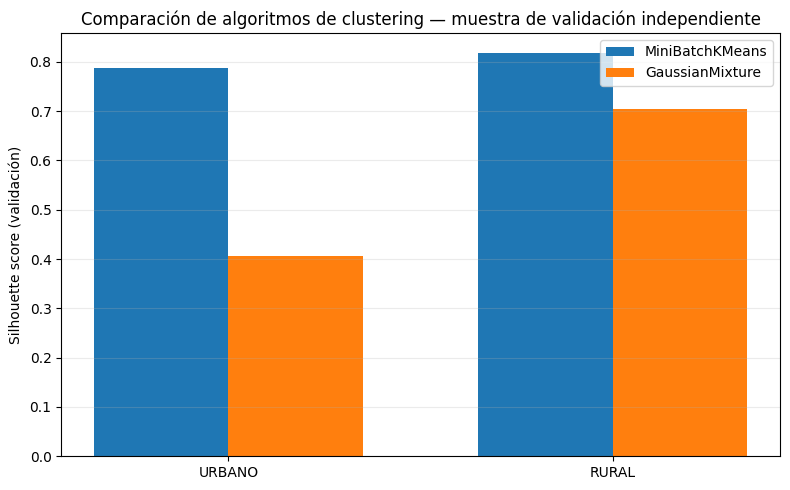

In [53]:
# ============================================================
# 15. EJECUTAR LA COMPARACIÓN — URBANO Y RURAL
# ============================================================

ajuste = {}

ajuste["URBANO"] = comparar_algoritmos_y_optimizar(
    urbanos, COLUMNAS_CLUSTERING, etiqueta="URBANO",
)
urbanos["cluster_tecnico"] = [f"urbano_{i}" for i in ajuste["URBANO"]["etiquetas"]]

ajuste["RURAL"] = comparar_algoritmos_y_optimizar(
    rurales, COLUMNAS_CLUSTERING, etiqueta="RURAL",
)
rurales["cluster_tecnico"] = [f"rural_{i}" for i in ajuste["RURAL"]["etiquetas"]]

resumen_comparacion_total = pd.concat(
    [ajuste["URBANO"]["resumen"], ajuste["RURAL"]["resumen"]], ignore_index=True,
)

print("\nRESUMEN FINAL DE LA COMPARACIÓN")
display(resumen_comparacion_total)

resumen_comparacion_total.to_csv(
    RUTA_COMPARACION_ALGORITMOS, index=False, encoding="utf-8-sig",
)
print("\nGuardado:", RUTA_COMPARACION_ALGORITMOS)

fig, ax = plt.subplots(figsize=(8, 5))
ancho = 0.35
subpoblaciones = resumen_comparacion_total["subpoblacion"].unique()

for offset, algoritmo in zip([-ancho / 2, ancho / 2], ["MiniBatchKMeans", "GaussianMixture"]):
    valores = [
        resumen_comparacion_total.loc[
            (resumen_comparacion_total["subpoblacion"] == sp)
            & (resumen_comparacion_total["algoritmo"] == algoritmo),
            "silhouette_validacion",
        ].iloc[0]
        for sp in subpoblaciones
    ]
    posiciones = np.arange(len(subpoblaciones)) + offset
    ax.bar(posiciones, valores, width=ancho, label=algoritmo)

ax.set_xticks(np.arange(len(subpoblaciones)))
ax.set_xticklabels(subpoblaciones)
ax.set_ylabel("Silhouette score (validación)")
ax.set_title("Comparación de algoritmos de clustering — muestra de validación independiente")
ax.legend()
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


## Traducir los clusters a segmentos de negocio

Los identificadores que devuelve el algoritmo (`urbano_0`, `rural_2`) son
arbitrarios y cambian entre corridas: no sirven para hablar con nadie fuera
del modelo. Aquí cada cluster se traduce a un **segmento de negocio** con
nombre claro, descripción, acción sugerida y prioridad operativa.

La traducción es por reglas explícitas sobre el perfil del cluster (no a mano),
así que se puede auditar, discutir con el área comercial y ajustar cambiando
un umbral. Los umbrales están arriba de la función, no enterrados en el código.


In [54]:
# ============================================================
# 16. CATÁLOGO DE SEGMENTOS DE NEGOCIO
# ============================================================
# Umbrales explícitos y discutibles con el área comercial.
# ============================================================

UMBRAL_CAIDA_FUERTE = -20.0        # %/mes: caída sostenida y severa
UMBRAL_CRECIMIENTO_FUERTE = 20.0   # %/mes: recuperación fuerte
UMBRAL_DESCENSO_SOSTENIDO = -1.0   # %/mes: descenso leve pero persistente
UMBRAL_CONSUMO_MARGINAL = 2.0      # kWh/mes: consumo prácticamente nulo
UMBRAL_CEROS_INTERMITENTE = 0.33   # 1/3 del año sin consumo

# Tramos de consumo: un segmento con el 56% de la población no es accionable,
# así que la base se abre además por nivel de consumo, que es el eje con el
# que el negocio ya trabaja.
TRAMOS_CONSUMO = [
    (30, "BAJO"),       # < 30 kWh/mes
    (100, "MEDIO"),     # 30 - 99
    (300, "ALTO"),      # 100 - 299
    (np.inf, "GRANDE"), # >= 300
]

CATALOGO_SEGMENTOS = {
    "BASE_ESTABLE": {
        "descripcion": "Consumo regular y predecible. Núcleo de ingresos.",
        "accion": "Monitoreo estándar. No requiere intervención.",
        "prioridad": 5,
        "prioridad_texto": "5 - Baja",
    },
    "BASE_EN_DESCENSO": {
        "descripcion": "Consumo regular pero con tendencia sostenida a la baja.",
        "accion": "Vigilar la tendencia. Entrada principal del estudio de caída.",
        "prioridad": 3,
        "prioridad_texto": "3 - Media",
    },
    "CAIDA_SEVERA": {
        "descripcion": "Caída fuerte y sostenida frente a su propio historial, con alta desviación respecto al promedio semestral reportado.",
        "accion": "Revisión prioritaria: verificar medidor, estado del predio y facturación.",
        "prioridad": 1,
        "prioridad_texto": "1 - Crítica",
    },
    "EN_COLAPSO": {
        "descripcion": "Consumo prácticamente nulo y cayendo hacia cero.",
        "accion": "Inspección en terreno: probable predio desocupado o medidor con falla.",
        "prioridad": 1,
        "prioridad_texto": "1 - Crítica",
    },
    "INTERMITENTE_CRITICO": {
        "descripcion": "Más de un tercio del año sin consumo y muy volátil.",
        "accion": "Verificar continuidad del servicio y confiabilidad de la lectura.",
        "prioridad": 2,
        "prioridad_texto": "2 - Alta",
    },
    "SIN_CONSUMO": {
        "descripcion": "Cero consumo en los 12 meses, pero sigue registrado como cliente.",
        "accion": "Depuración de catastro: normalizar, suspender o retirar del padrón.",
        "prioridad": 2,
        "prioridad_texto": "2 - Alta",
    },
    "EN_REACTIVACION": {
        "descripcion": "Consumo creciendo con fuerza desde niveles casi nulos.",
        "accion": "Confirmar reconexión o nuevo ocupante y ajustar la proyección de demanda.",
        "prioridad": 4,
        "prioridad_texto": "4 - Informativa",
    },
    "NUEVO_O_SIN_DATOS": {
        "descripcion": "Menos de 6 meses de historia válida en la ventana.",
        "accion": "Esperar historia. Excluir de cualquier análisis de tendencia.",
        "prioridad": 5,
        "prioridad_texto": "5 - Baja",
    },
}

# Segmentos que se abren por tramo de consumo (los masivos)
SEGMENTOS_CON_TRAMO = {"BASE_ESTABLE", "BASE_EN_DESCENSO"}


def clasificar_segmento_negocio(mediana, pct_ceros, pendiente):
    """Traduce el perfil de un cluster a un segmento de negocio.
    El orden de las reglas importa: va de la condición más grave a la más leve."""

    if pd.isna(pct_ceros):
        return "NUEVO_O_SIN_DATOS"

    if pct_ceros >= 1.0:
        return "SIN_CONSUMO"

    if pct_ceros >= UMBRAL_CEROS_INTERMITENTE:
        return "INTERMITENTE_CRITICO"

    if pd.isna(pendiente):
        return "BASE_ESTABLE"

    if pendiente < UMBRAL_CAIDA_FUERTE:
        if pd.notna(mediana) and mediana < UMBRAL_CONSUMO_MARGINAL:
            return "EN_COLAPSO"
        return "CAIDA_SEVERA"

    if pendiente > UMBRAL_CRECIMIENTO_FUERTE:
        return "EN_REACTIVACION"

    if pendiente < UMBRAL_DESCENSO_SOSTENIDO:
        return "BASE_EN_DESCENSO"

    return "BASE_ESTABLE"


def asignar_tramo(mediana):
    if pd.isna(mediana):
        return "SIN_DATO"
    for corte, nombre in TRAMOS_CONSUMO:
        if mediana < corte:
            return nombre
    return "GRANDE"


def segmentar_subpoblacion(datos, zona):
    """Asigna segmento de negocio a cada cliente a partir del perfil de SU cluster."""

    perfil = datos.groupby("cluster_tecnico").agg(
        mediana=("mediana_12m_kwh", "median"),
        pct_ceros=("pct_ceros_12m", "median"),
        pendiente=("pendiente_pct_mensual_12m", "median"),
    )

    mapa = {
        cluster: clasificar_segmento_negocio(
            fila["mediana"], fila["pct_ceros"], fila["pendiente"]
        )
        for cluster, fila in perfil.iterrows()
    }

    salida = datos.copy()
    salida["segmento_base"] = salida["cluster_tecnico"].map(mapa)
    salida["zona"] = zona
    # El mapa se guarda: es lo que mantiene estables los nombres de negocio
    # entre corridas, y sin él un modelo cargado devolvería solo números.
    ajuste[zona]["mapa_segmentos"] = mapa

    print(f"\n{zona}")
    print("-" * 70)
    for cluster, fila in perfil.iterrows():
        n = int((datos["cluster_tecnico"] == cluster).sum())
        print(
            f"  {cluster:<12} n={n:>7,} | {fila['mediana']:>8.2f} kWh | "
            f"ceros {fila['pct_ceros']:.0%} | {fila['pendiente']:>9.1f} %/mes "
            f"-> {mapa[cluster]}"
        )

    return salida


print("TRADUCCIÓN DE CLUSTERS A SEGMENTOS DE NEGOCIO")
print("=" * 70)

urbanos = segmentar_subpoblacion(urbanos, "URBANO")
rurales = segmentar_subpoblacion(rurales, "RURAL")


TRADUCCIÓN DE CLUSTERS A SEGMENTOS DE NEGOCIO

URBANO
----------------------------------------------------------------------
  urbano_0     n=330,807 |    77.00 kWh | ceros 0% |      -0.1 %/mes -> BASE_ESTABLE
  urbano_1     n=  9,570 |     7.00 kWh | ceros 17% |     -38.5 %/mes -> CAIDA_SEVERA
  urbano_2     n=  6,288 |     5.00 kWh | ceros 25% |      54.9 %/mes -> EN_REACTIVACION

RURAL
----------------------------------------------------------------------
  rural_0      n=186,882 |    37.07 kWh | ceros 0% |      -0.1 %/mes -> BASE_ESTABLE
  rural_1      n=  5,015 |     1.71 kWh | ceros 17% |      63.4 %/mes -> EN_REACTIVACION
  rural_2      n=  7,585 |     2.28 kWh | ceros 17% |     -42.9 %/mes -> CAIDA_SEVERA


## Consolidar, perfilar e interpretar los clusters

In [55]:
# ============================================================
# 17. CONSOLIDAR Y CONSTRUIR EL NOMBRE FINAL DEL SEGMENTO
# ============================================================

asignaciones = pd.concat(
    [
        urbanos[["NIU", "segmento_base", "zona", "cluster_tecnico"]].assign(asignado_por="algoritmo"),
        rurales[["NIU", "segmento_base", "zona", "cluster_tecnico"]].assign(asignado_por="algoritmo"),
        segmento_regla.assign(
            segmento_base="SIN_CONSUMO",
            zona=np.where(segmento_regla["es_rural_final"], "RURAL", "URBANO"),
            cluster_tecnico="regla_cero",
        )[["NIU", "segmento_base", "zona", "cluster_tecnico", "asignado_por"]],
    ],
    ignore_index=True,
)

if asignaciones["NIU"].duplicated().any():
    raise ValueError("Hay NIU asignados a más de un segmento — revisar la separación por regla.")

clientes_clusters = features_clientes.merge(asignaciones, on="NIU", how="left")

# Los que no alcanzaron historia mínima
sin_historia = clientes_clusters["segmento_base"].isna()
clientes_clusters.loc[sin_historia, "segmento_base"] = "NUEVO_O_SIN_DATOS"
clientes_clusters.loc[sin_historia, "asignado_por"] = "regla"
clientes_clusters.loc[sin_historia, "cluster_tecnico"] = "regla_sin_historia"
clientes_clusters.loc[sin_historia, "zona"] = np.where(
    clientes_clusters.loc[sin_historia, "es_rural_final"], "RURAL", "URBANO",
)

# --- Tramo de consumo (abre los segmentos masivos) ---
clientes_clusters["tramo_consumo"] = clientes_clusters["mediana_12m_kwh"].map(asignar_tramo)

# --- Nombre final del segmento ---
usa_tramo = clientes_clusters["segmento_base"].isin(SEGMENTOS_CON_TRAMO)

clientes_clusters["cluster_id"] = np.where(
    usa_tramo,
    clientes_clusters["zona"] + "_" + clientes_clusters["segmento_base"]
        + "_" + clientes_clusters["tramo_consumo"],
    clientes_clusters["zona"] + "_" + clientes_clusters["segmento_base"],
)

# NUEVO_O_SIN_DATOS no se separa por zona: no hay historia para afirmar nada de ellos
clientes_clusters.loc[
    clientes_clusters["segmento_base"] == "NUEVO_O_SIN_DATOS", "cluster_id"
] = "NUEVO_O_SIN_DATOS"

# --- Descripción, acción y prioridad desde el catálogo ---
for campo in ["descripcion", "accion", "prioridad", "prioridad_texto"]:
    clientes_clusters[f"segmento_{campo}"] = clientes_clusters["segmento_base"].map(
        lambda s: CATALOGO_SEGMENTOS[s][campo]
    )

print(f"Clientes totales: {len(clientes_clusters):,}")

print("\nSEGMENTOS DE NEGOCIO — DISTRIBUCIÓN FINAL")
print("=" * 70)
distribucion = (
    clientes_clusters
    .groupby(["segmento_prioridad_texto", "cluster_id"])
    .agg(
        n_clientes=("NIU", "size"),
        consumo_mediano_kwh=("mediana_12m_kwh", "median"),
        tendencia_pct_mes=("pendiente_pct_mensual_12m", "median"),
    )
    .reset_index()
    .sort_values(["segmento_prioridad_texto", "n_clientes"], ascending=[True, False])
)
distribucion["pct_poblacion"] = (
    distribucion["n_clientes"] / len(clientes_clusters) * 100
).round(2)
display(distribucion)

clientes_clusters.to_parquet(RUTA_CLUSTERS, index=False, engine="pyarrow")
print("\nGuardado:", RUTA_CLUSTERS)


Clientes totales: 592,159

SEGMENTOS DE NEGOCIO — DISTRIBUCIÓN FINAL


,segmento_prioridad_texto,cluster_id,n_clientes,consumo_mediano_kwh,tendencia_pct_mes,pct_poblacion
1,1 - Crítica,URBANO_CAIDA_SEVERA,9570,7.000000,-38.535707,1.62
0,1 - Crítica,RURAL_CAIDA_SEVERA,7585,2.283288,-42.991071,1.28
2,2 - Alta,RURAL_SIN_CONSUMO,15794,0.000000,NaN,2.67
3,2 - Alta,URBANO_SIN_CONSUMO,8427,0.000000,NaN,1.42
5,4 - Informativa,URBANO_EN_REACTIVACION,6288,5.000000,54.895105,1.06
4,4 - Informativa,RURAL_EN_REACTIVACION,5015,1.709098,63.419412,0.85
14,5 - Baja,URBANO_BASE_ESTABLE_MEDIO,163299,63.500000,-0.177288,27.58
11,5 - Baja,URBANO_BASE_ESTABLE_ALTO,98685,138.000000,-0.075868,16.67
10,5 - Baja,RURAL_BASE_ESTABLE_MEDIO,82617,53.116669,-0.069532,13.95
8,5 - Baja,RURAL_BASE_ESTABLE_BAJO,79578,7.733980,-0.146273,13.44



Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\clientes_clusters_consumo.parquet


In [56]:
# ============================================================
# 17b. CATÁLOGO DE SEGMENTOS PARA NEGOCIO (LO QUE SE COMPARTE)
# ============================================================
# Una fila por segmento con su tamaño, su perfil y qué hacer con él.
# Esta es la tabla que se lleva a una reunión, no la de features.
# ============================================================

catalogo_negocio = (
    clientes_clusters
    .groupby(["cluster_id", "segmento_base"])
    .agg(
        n_clientes=("NIU", "size"),
        consumo_mediano_kwh=("mediana_12m_kwh", "median"),
        variabilidad=("cv_interno", "median"),
        meses_en_cero_pct=("pct_ceros_12m", "median"),
        tendencia_pct_mes=("pendiente_pct_mensual_12m", "median"),
    )
    .reset_index()
)

catalogo_negocio["pct_poblacion"] = (
    catalogo_negocio["n_clientes"] / len(clientes_clusters) * 100
).round(2)

catalogo_negocio["descripcion"] = catalogo_negocio["segmento_base"].map(
    lambda s: CATALOGO_SEGMENTOS[s]["descripcion"]
)
catalogo_negocio["accion_sugerida"] = catalogo_negocio["segmento_base"].map(
    lambda s: CATALOGO_SEGMENTOS[s]["accion"]
)
catalogo_negocio["prioridad"] = catalogo_negocio["segmento_base"].map(
    lambda s: CATALOGO_SEGMENTOS[s]["prioridad_texto"]
)

catalogo_negocio = catalogo_negocio.sort_values(
    ["prioridad", "n_clientes"], ascending=[True, False]
).reset_index(drop=True)

columnas_negocio = [
    "prioridad", "cluster_id", "n_clientes", "pct_poblacion",
    "consumo_mediano_kwh", "tendencia_pct_mes",
    "descripcion", "accion_sugerida",
]

display(catalogo_negocio[columnas_negocio])

catalogo_negocio.to_csv(RUTA_CATALOGO_NEGOCIO, index=False, encoding="utf-8-sig")
print("\nGuardado:", RUTA_CATALOGO_NEGOCIO)

print("\nCLIENTES QUE REQUIEREN ACCIÓN (prioridad 1 y 2)")
print("-" * 70)
accionables = clientes_clusters[clientes_clusters["segmento_prioridad"] <= 2]
print(
    f"{len(accionables):,} clientes "
    f"({len(accionables) / len(clientes_clusters) * 100:.1f}% de la población)"
)
display(
    accionables["cluster_id"].value_counts().rename("n_clientes").to_frame()
)


,prioridad,cluster_id,n_clientes,pct_poblacion,consumo_mediano_kwh,tendencia_pct_mes,descripcion,accion_sugerida
0,1 - Crítica,URBANO_CAIDA_SEVERA,9570,1.62,7.000000,-38.535707,Caída fuerte y sostenida frente a su propio hi...,"Revisión prioritaria: verificar medidor, estad..."
1,1 - Crítica,RURAL_CAIDA_SEVERA,7585,1.28,2.283288,-42.991071,Caída fuerte y sostenida frente a su propio hi...,"Revisión prioritaria: verificar medidor, estad..."
2,2 - Alta,RURAL_SIN_CONSUMO,15794,2.67,0.000000,NaN,"Cero consumo en los 12 meses, pero sigue regis...","Depuración de catastro: normalizar, suspender ..."
3,2 - Alta,URBANO_SIN_CONSUMO,8427,1.42,0.000000,NaN,"Cero consumo en los 12 meses, pero sigue regis...","Depuración de catastro: normalizar, suspender ..."
4,4 - Informativa,URBANO_EN_REACTIVACION,6288,1.06,5.000000,54.895105,Consumo creciendo con fuerza desde niveles cas...,Confirmar reconexión o nuevo ocupante y ajusta...
5,4 - Informativa,RURAL_EN_REACTIVACION,5015,0.85,1.709098,63.419412,Consumo creciendo con fuerza desde niveles cas...,Confirmar reconexión o nuevo ocupante y ajusta...
6,5 - Baja,URBANO_BASE_ESTABLE_MEDIO,163299,27.58,63.500000,-0.177288,Consumo regular y predecible. Núcleo de ingresos.,Monitoreo estándar. No requiere intervención.
7,5 - Baja,URBANO_BASE_ESTABLE_ALTO,98685,16.67,138.000000,-0.075868,Consumo regular y predecible. Núcleo de ingresos.,Monitoreo estándar. No requiere intervención.
8,5 - Baja,RURAL_BASE_ESTABLE_MEDIO,82617,13.95,53.116669,-0.069532,Consumo regular y predecible. Núcleo de ingresos.,Monitoreo estándar. No requiere intervención.
9,5 - Baja,RURAL_BASE_ESTABLE_BAJO,79578,13.44,7.733980,-0.146273,Consumo regular y predecible. Núcleo de ingresos.,Monitoreo estándar. No requiere intervención.



Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\catalogo_segmentos_negocio.csv

CLIENTES QUE REQUIEREN ACCIÓN (prioridad 1 y 2)
----------------------------------------------------------------------
41,376 clientes (7.0% de la población)


,n_clientes
cluster_id,
RURAL_SIN_CONSUMO,15794
URBANO_CAIDA_SEVERA,9570
URBANO_SIN_CONSUMO,8427
RURAL_CAIDA_SEVERA,7585


In [57]:
# ============================================================
# 18. PERFIL DE CADA SEGMENTO
# ============================================================

perfil_clusters = (
    clientes_clusters[clientes_clusters["segmento_base"] != "NUEVO_O_SIN_DATOS"]
    .groupby(["cluster_id", "asignado_por"])
    .agg(
        n_clientes=("NIU", "size"),
        mediana_12m_kwh=("mediana_12m_kwh", "median"),
        cv_interno=("cv_interno", "median"),
        pct_ceros_12m=("pct_ceros_12m", "median"),
        pendiente_pct_mensual_12m=("pendiente_pct_mensual_12m", "median"),
        cv_vs_semestral=("cv_vs_semestral", "median"),
    )
    .reset_index()
    .sort_values("n_clientes", ascending=False)
)

perfil_clusters["pct_poblacion"] = (
    perfil_clusters["n_clientes"] / len(clientes_clusters) * 100
).round(2)

display(perfil_clusters)

# --- Chequeo de salud de la segmentación ---
print("\nCHEQUEO DE SALUD DE LA SEGMENTACIÓN")
print("-" * 70)

for etiqueta, total in [
    ("URBANO", len(urbanos)),
    ("RURAL", len(rurales)),
]:
    del_algoritmo = perfil_clusters[
        (perfil_clusters["asignado_por"] == "algoritmo")
        & (perfil_clusters["cluster_id"].str.startswith(etiqueta + "_"))
    ]
    if del_algoritmo.empty:
        continue
    share_max = del_algoritmo["n_clientes"].max() / total * 100
    share_min = del_algoritmo["n_clientes"].min() / total * 100
    print(
        f"{etiqueta}: {len(del_algoritmo)} clusters | "
        f"mayor = {share_max:.1f}% | menor = {share_min:.2f}% de la subpoblación activa"
    )
    if share_max > 70:
        print("  ⚠ Un cluster concentra más del 70%: la segmentación sigue poco discriminante.")
    if share_min < MIN_SHARE_CLUSTER * 100:
        print("  ⚠ Hay un cluster por debajo del mínimo de tamaño.")

perfil_clusters.to_csv(RUTA_PERFIL_CLUSTERS, index=False, encoding="utf-8-sig")
print("\nGuardado:", RUTA_PERFIL_CLUSTERS)


,cluster_id,asignado_por,n_clientes,mediana_12m_kwh,cv_interno,pct_ceros_12m,pendiente_pct_mensual_12m,cv_vs_semestral,pct_poblacion
10,URBANO_BASE_ESTABLE_MEDIO,algoritmo,163299,63.500000,0.178454,0.000000,-0.177288,0.178921,27.58
7,URBANO_BASE_ESTABLE_ALTO,algoritmo,98685,138.000000,0.137465,0.000000,-0.075868,0.137397,16.67
3,RURAL_BASE_ESTABLE_MEDIO,algoritmo,82617,53.116669,0.176506,0.000000,-0.069532,0.176263,13.95
1,RURAL_BASE_ESTABLE_BAJO,algoritmo,79578,7.733980,0.365009,0.000000,-0.146273,0.341899,13.44
8,URBANO_BASE_ESTABLE_BAJO,algoritmo,50073,12.500000,0.424955,0.000000,0.000000,0.446348,8.46
0,RURAL_BASE_ESTABLE_ALTO,algoritmo,22189,133.333328,0.171313,0.000000,-0.068731,0.169557,3.75
9,URBANO_BASE_ESTABLE_GRANDE,algoritmo,18750,527.500000,0.127804,0.000000,0.012088,0.126769,3.17
6,RURAL_SIN_CONSUMO,regla,15794,0.000000,NaN,1.000000,NaN,0.000000,2.67
11,URBANO_CAIDA_SEVERA,algoritmo,9570,7.000000,2.557006,0.166667,-38.535707,3.005976,1.62
13,URBANO_SIN_CONSUMO,regla,8427,0.000000,NaN,1.000000,NaN,0.000000,1.42



CHEQUEO DE SALUD DE LA SEGMENTACIÓN
----------------------------------------------------------------------
URBANO: 6 clusters | mayor = 47.1% | menor = 1.81% de la subpoblación activa
RURAL: 6 clusters | mayor = 41.4% | menor = 1.25% de la subpoblación activa

Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\perfil_clusters_resumen.csv


## Guardar el modelo para reutilizarlo

Sin esto, clasificar un cliente nuevo obligaría a repetir todo el agrupamiento
—y el mes entrante, con la ventana desplazada, los clusters saldrían distintos
y los segmentos dejarían de ser comparables entre corridas.

Se guarda todo lo necesario para transformar y clasificar sin reagrupar: el
modelo ajustado, el escalador, los límites de winsorización, el orden exacto de
las columnas, el mapa a nombres de negocio y los umbrales del catálogo.


In [58]:
# ============================================================
# 20. GUARDAR EL MODELO DE AGRUPAMIENTO
# ============================================================

artefacto = {
    "version": "1.0",
    "fecha_entrenamiento": pd.Timestamp.now().isoformat(timespec="seconds"),
    "semilla": SEED,

    # Ventana con la que se construyeron las features
    "ventana": {
        "inicio": meses_12[0].isoformat(),
        "fin": meses_12[-1].isoformat(),
        "n_meses": len(meses_12),
        "retroceso_aplicado": MESES_RETROCESO_VENTANA,
        "ultimo_periodo_serie": periodo_max.isoformat(),
    },

    # Contrato de features: el orden importa, el modelo espera esta secuencia
    "columnas_clustering": list(COLUMNAS_CLUSTERING),
    "columnas_winsor": list(COLUMNAS_WINSOR),
    "min_meses_validos": MIN_MESES_VALIDOS_12,

    # Reglas de negocio, para que el scoring produzca los mismos nombres
    "catalogo_segmentos": CATALOGO_SEGMENTOS,
    "segmentos_con_tramo": sorted(SEGMENTOS_CON_TRAMO),
    "tramos_consumo": [(float(c), n) for c, n in TRAMOS_CONSUMO],
    "umbrales_negocio": {
        "UMBRAL_CAIDA_FUERTE": UMBRAL_CAIDA_FUERTE,
        "UMBRAL_CRECIMIENTO_FUERTE": UMBRAL_CRECIMIENTO_FUERTE,
        "UMBRAL_DESCENSO_SOSTENIDO": UMBRAL_DESCENSO_SOSTENIDO,
        "UMBRAL_CONSUMO_MARGINAL": UMBRAL_CONSUMO_MARGINAL,
        "UMBRAL_CEROS_INTERMITENTE": UMBRAL_CEROS_INTERMITENTE,
    },

    "subpoblaciones": {},
}

for zona in ["URBANO", "RURAL"]:
    a = ajuste[zona]
    artefacto["subpoblaciones"][zona] = {
        "algoritmo": a["algoritmo"],
        "hiperparametros": a["hiperparametros"],
        "modelo": a["modelo"],
        "scaler": a["preproceso"]["scaler"],
        "limites_winsor": a["preproceso"]["limites"],
        "mapa_segmentos": a["mapa_segmentos"],
        "n_entrenamiento": a["n_entrenamiento"],
    }

joblib.dump(artefacto, RUTA_MODELOS, compress=3)

print("MODELO DE AGRUPAMIENTO GUARDADO")
print("=" * 70)
print("Ruta:", RUTA_MODELOS)
print(f"Tamaño: {RUTA_MODELOS.stat().st_size / 1024:.1f} KB")
print(f"\nVentana: {meses_12[0]:%Y-%m} → {meses_12[-1]:%Y-%m}")
for zona, d in artefacto["subpoblaciones"].items():
    print(f"\n{zona}")
    print(f"  algoritmo       : {d['algoritmo']}")
    print(f"  entrenado sobre : {d['n_entrenamiento']:,} clientes")
    print(f"  segmentos       : {sorted(set(d['mapa_segmentos'].values()))}")

# --- Verificación: el modelo guardado reproduce las mismas etiquetas ---
print("\nVERIFICACIÓN DE INTEGRIDAD")
print("-" * 70)
recargado = joblib.load(RUTA_MODELOS)

for zona, datos_zona in [("URBANO", urbanos), ("RURAL", rurales)]:
    d = recargado["subpoblaciones"][zona]

    preproceso_rec = {
        "limites": d["limites_winsor"],
        "scaler": d["scaler"],
        "columnas": recargado["columnas_clustering"],
    }
    X = aplicar_preproceso(
        datos_zona, recargado["columnas_clustering"], preproceso_rec,
    )
    etiquetas_rec = d["modelo"].predict(X)

    prefijo = "urbano" if zona == "URBANO" else "rural"
    esperadas = datos_zona["cluster_tecnico"].to_numpy()
    obtenidas = np.array([f"{prefijo}_{i}" for i in etiquetas_rec])

    iguales = bool((esperadas == obtenidas).all())
    print(f"  {zona}: reproduce las mismas etiquetas -> {iguales}")
    if not iguales:
        n_dif = int((esperadas != obtenidas).sum())
        raise ValueError(
            f"El modelo guardado no reproduce el agrupamiento en {zona}: "
            f"{n_dif:,} clientes difieren."
        )

print("\n✓ El modelo guardado reproduce exactamente la segmentación.")


MODELO DE AGRUPAMIENTO GUARDADO
Ruta: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\modelo_agrupamiento.joblib
Tamaño: 71.0 KB

Ventana: 2025-01 → 2025-12

URBANO
  algoritmo       : MiniBatchKMeans
  entrenado sobre : 346,665 clientes
  segmentos       : ['BASE_ESTABLE', 'CAIDA_SEVERA', 'EN_REACTIVACION']

RURAL
  algoritmo       : MiniBatchKMeans
  entrenado sobre : 199,482 clientes
  segmentos       : ['BASE_ESTABLE', 'CAIDA_SEVERA', 'EN_REACTIVACION']

VERIFICACIÓN DE INTEGRIDAD
----------------------------------------------------------------------
  URBANO: reproduce las mismas etiquetas -> True
  RURAL: reproduce las mismas etiquetas -> True

✓ El modelo guardado reproduce exactamente la segmentación.


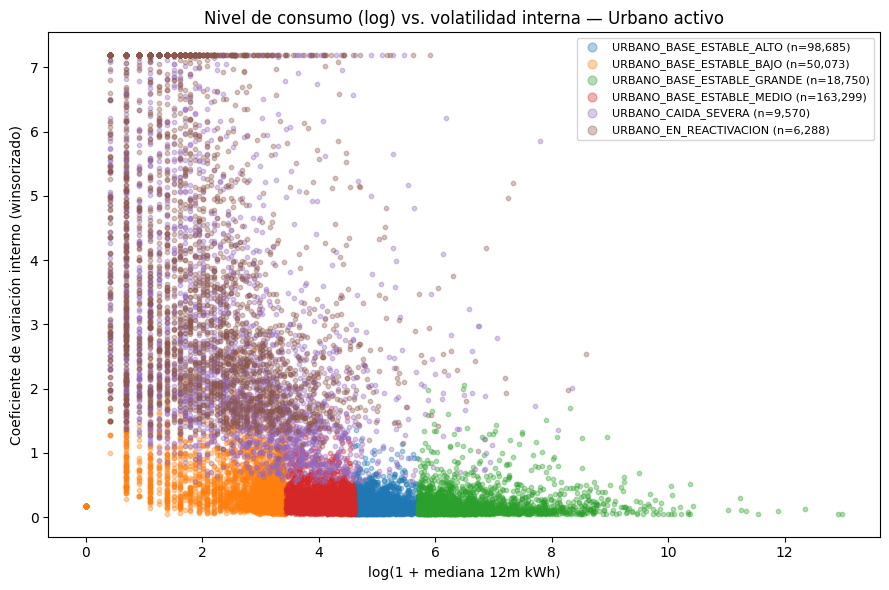

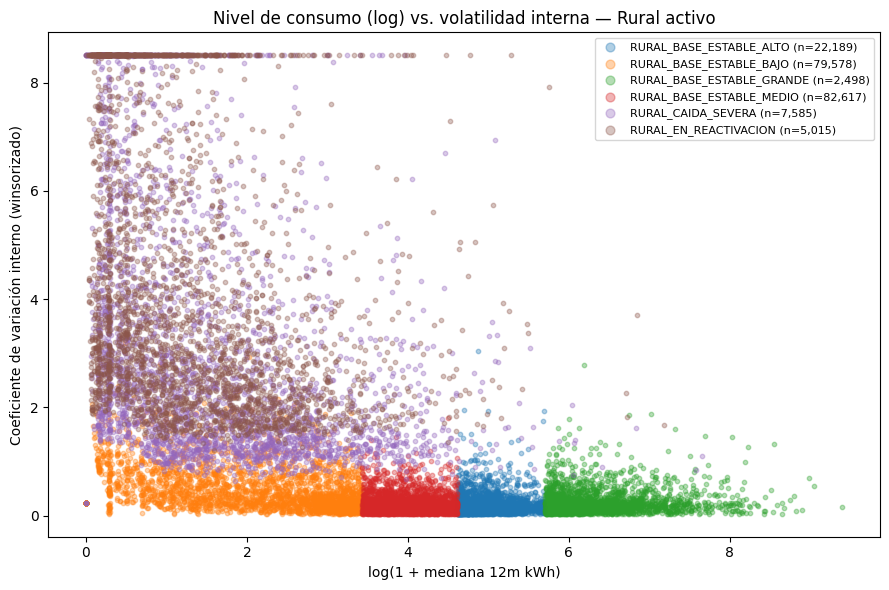

AGRUPAMIENTO DE CLIENTES — TERMINADO

Salidas:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\features_clientes_consumo.parquet
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\clientes_clusters_consumo.parquet (esta es la que lee el estudio de caída de consumo)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\catalogo_segmentos_negocio.csv (tabla para negocio: qué es cada segmento y qué hacer)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\modelo_agrupamiento.joblib (modelo + scaler + mapa: para clasificar sin reagrupar)
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\perfil_clusters_resumen.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\auditoria_promedio_semestral.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\agrupamiento_clientes\comparacion_algoritmos_clustering.cs

In [59]:
# ============================================================
# 19. GRÁFICA: NIVEL DE CONSUMO VS. VOLATILIDAD, COLOREADO POR CLUSTER
# ============================================================
# Se grafica sobre las features winsorizadas, que son las que el algoritmo
# realmente vio — graficar las crudas mostraría una nube aplastada contra el
# eje por culpa de los mismos extremos que ya recortamos.

nombres_por_niu = clientes_clusters.set_index("NIU")["cluster_id"]

for etiqueta, datos in [("Urbano", urbanos), ("Rural", rurales)]:

    datos = datos.assign(cluster_id=datos["NIU"].map(nombres_por_niu))

    limites_cv = (
        datos["cv_interno"].quantile(WINSOR_P_BAJO / 100),
        datos["cv_interno"].quantile(WINSOR_P_ALTO / 100),
    )

    plt.figure(figsize=(9, 6))

    for cluster_id, grupo in datos.groupby("cluster_id"):
        muestra = grupo.sample(n=min(3000, len(grupo)), random_state=SEED)
        plt.scatter(
            muestra["mediana_12m_kwh_log"],
            muestra["cv_interno"].clip(*limites_cv),
            alpha=0.35, s=10, label=f"{cluster_id} (n={len(grupo):,})",
        )

    plt.title(f"Nivel de consumo (log) vs. volatilidad interna — {etiqueta} activo")
    plt.xlabel("log(1 + mediana 12m kWh)")
    plt.ylabel("Coeficiente de variación interno (winsorizado)")
    plt.legend(markerscale=2, fontsize=8)
    plt.tight_layout()
    plt.show()

print("AGRUPAMIENTO DE CLIENTES — TERMINADO")
print("=" * 70)
print("\nSalidas:")
print(" •", RUTA_FEATURES_CLIENTES)
print(" •", RUTA_CLUSTERS, "(esta es la que lee el estudio de caída de consumo)")
print(" •", RUTA_CATALOGO_NEGOCIO, "(tabla para negocio: qué es cada segmento y qué hacer)")
print(" •", RUTA_MODELOS, "(modelo + scaler + mapa: para clasificar sin reagrupar)")
print(" •", RUTA_PERFIL_CLUSTERS)
print(" •", RUTA_AUDITORIA_SEMESTRAL)
print(" •", RUTA_COMPARACION_ALGORITMOS)
